### Importing data and important packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Data/stud.csv")
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Checking for missing and duplicate values

In [4]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### Checking Data Types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [23]:
cols = ['gender', 'race_ethnicity', 'parental_level_of_education',
        'lunch', 'test_preparation_course']

df[cols] = df[cols].astype('object')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Statistics of dataset

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Exploring Data

In [15]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [25]:
print("categories in variable 'gender': {}".format(df['gender'].unique()))

print("\ncategories in variable 'race_ethnicity': {}".format(df['race_ethnicity'].unique()))

print("\ncategories in variable 'parental_level_of_education': {}".format(df['parental_level_of_education'].unique()))

print("\ncategories in variable 'lunch': {}".format(df['lunch'].unique()))

print("\ncategories in variable 'test_preparation_course': {}".format(df['test_preparation_course'].unique()))

categories in variable 'gender': ['female' 'male']

categories in variable 'race_ethnicity': ['group B' 'group C' 'group A' 'group D' 'group E']

categories in variable 'parental_level_of_education': ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

categories in variable 'lunch': ['standard' 'free/reduced']

categories in variable 'test_preparation_course': ['none' 'completed']


In [29]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object']

print('There are {} numerical features: {}'.format(len(numeric_features),numeric_features))
print('There are {} categorical features: {}'.format(len(categorical_features),categorical_features))

There are 3 numerical features: ['math_score', 'reading_score', 'writing_score']
There are 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Adding columns for 'Total Score' & 'Average Score'

In [37]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [40]:
math_full = df[df['math_score']==100]['average_score'].count()
reading_full = df[df['reading_score']==100]['average_score'].count()
writing_full = df[df['writing_score']==100]['average_score'].count()

print(f'No.of students with full marks in maths: {math_full}')
print(f'No.of students with full marks in reading: {reading_full}')
print(f'No.of students with full marks in writing: {writing_full}')

No.of students with full marks in maths: 7
No.of students with full marks in reading: 17
No.of students with full marks in writing: 14


In [41]:
math_fail = df[df['math_score']<=35]['average_score'].count()
reading_fail = df[df['reading_score']<=35]['average_score'].count()
writing_fail = df[df['writing_score']<=35]['average_score'].count()

print(f'No.of students failed in maths: {math_fail}')
print(f'No.of students failed in reading: {reading_fail}')
print(f'No.of students failed in writing: {writing_fail}')

No.of students failed in maths: 27
No.of students failed in reading: 15
No.of students failed in writing: 18


###  Insights
 - From above observation we get to know that students have performed worst in Maths 
 - Best performance is in reading section

### Exploring Data (Visualization)

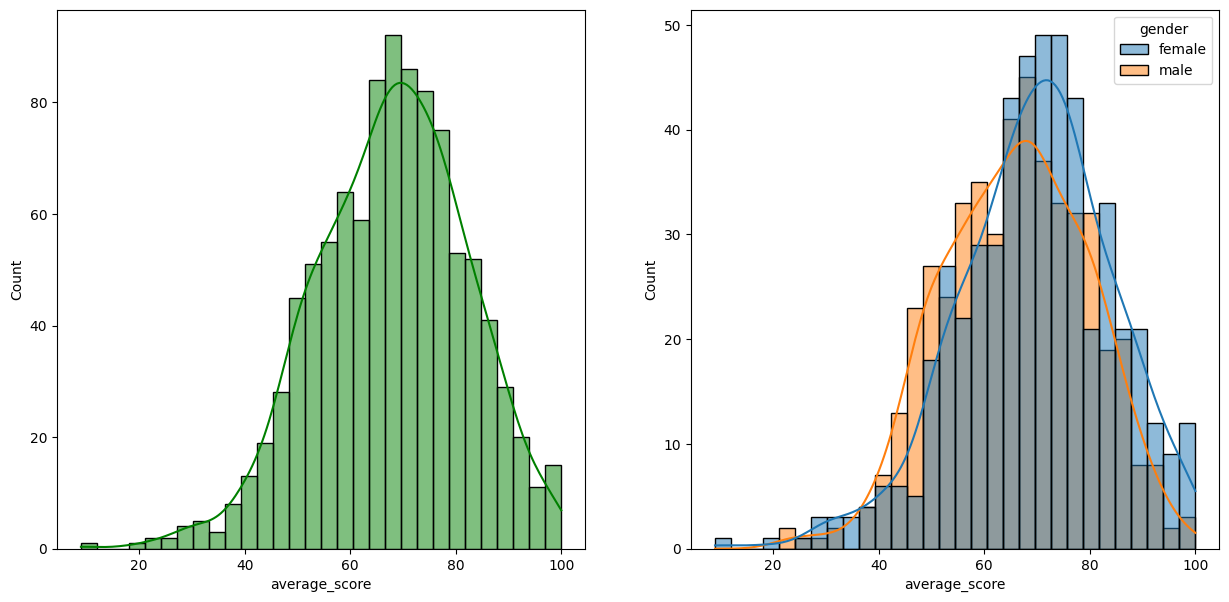

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average_score',bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average_score', bins=30, kde=True, hue='gender')
plt.show()

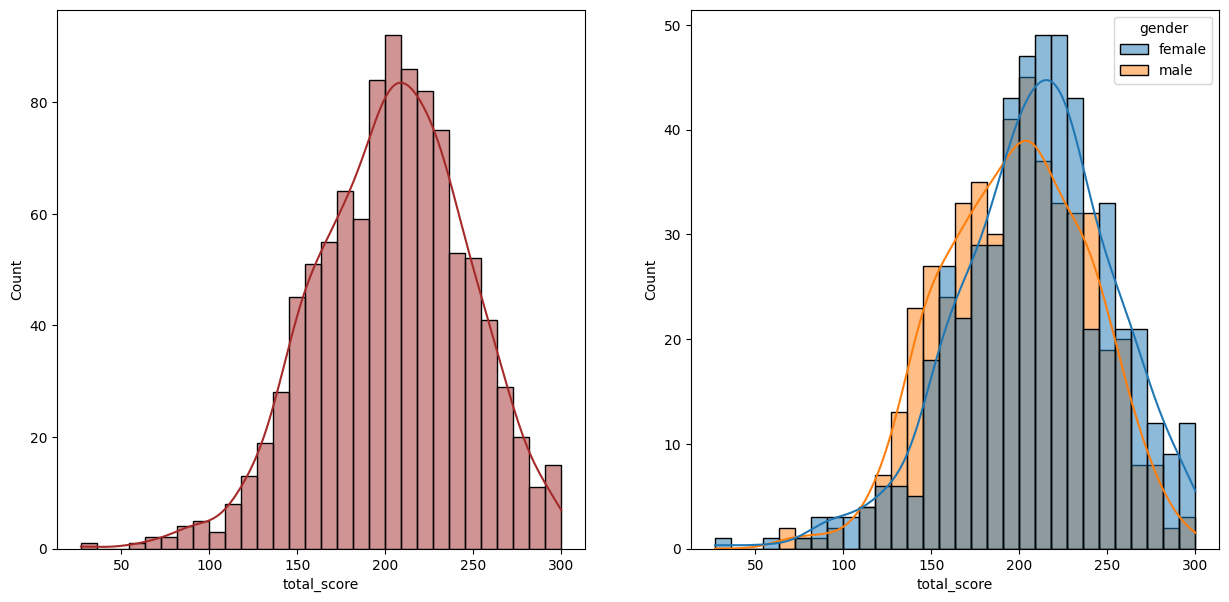

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color='Brown')
plt.subplot(122)
sns.histplot(data=df, x='total_score', bins=30, kde=True, hue='gender')
plt.show()

### Observation:

 - Female students tend to perform better than male students.